# Simple model

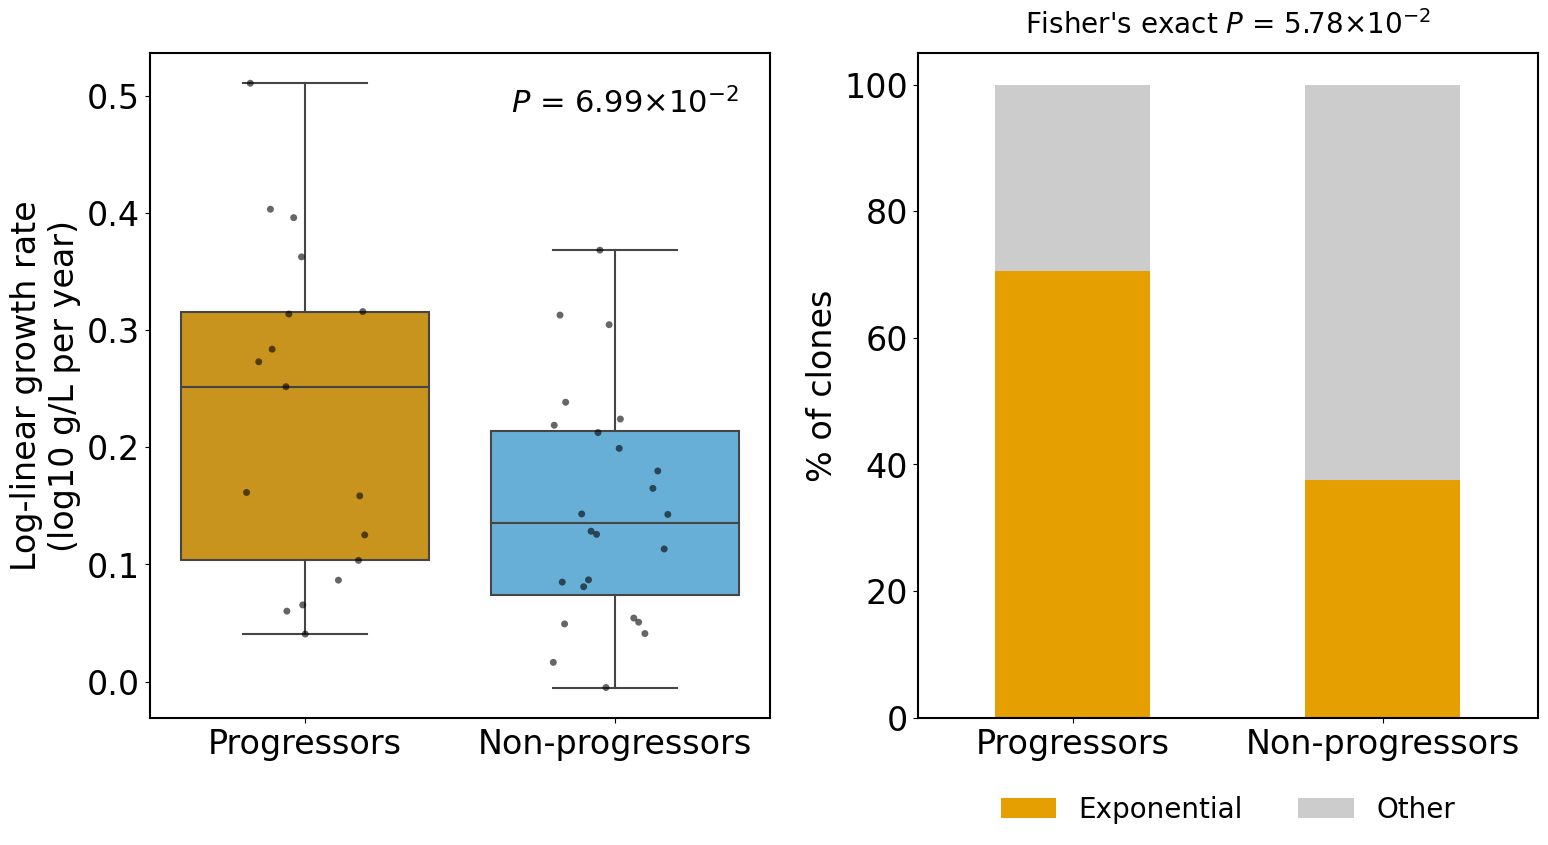

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from scipy.stats import linregress, mannwhitneyu, fisher_exact
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '../data/PLCO_ms_clone.csv'
FIG_DIR = '../00.Figures'

mm_progressing_clones = ['E-032997-1Clone_1', 'E-032997-1Clone_3', 'E-066387-4Clone_1', 'F-143995-1Clone_2', 'F-157972-3Clone_1', 'H-049677-0Clone_1', 'I-087748-3Clone_1', 'N-004423-0Clone_1', 'P-009501-9Clone_1', 'Q-017017-6Clone_1', 'R-016550-7Clone_5', 'R-121148-2Clone_1', 'R-125090-1Clone_1', 'S-004464-4Clone_1', 'S-043218-8Clone_1', 'V-051474-6Clone_1', 'V-051474-6Clone_3', 'W-055282-9Clone_2']
mgus_progressing_clones = ['A-054584-0Clone_1', 'A-085562-9Clone_1', 'A-117449-0Clone_3', 'B-094914-1Clone_1', 'B-094914-1Clone_2', 'C-038737-5Clone_4', 'C-096391-9Clone_1', 'J-088487-6Clone_1', 'K-004231-7Clone_5', 'M-052041-2Clone_3', 'M-097499-0Clone_3', 'O-010904-2Clone_1', 'P-061116-2Clone_1', 'P-116700-7Clone_4', 'Q-030535-1Clone_1', 'Q-095002-3Clone_1', 'S-040365-0Clone_6', 'S-067230-4Clone_3', 'S-113265-4Clone_3', 'S-113265-4Clone_7', 'T-090433-5Clone_1', 'T-104671-4Clone_1', 'U-002549-6Clone_4', 'U-034418-5Clone_1', 'U-038126-0Clone_2', 'U-071084-9Clone_2', 'V-046380-2Clone_1', 'V-074082-0Clone_4', 'V-093621-3Clone_1', 'V-093621-3Clone_2', 'V-137118-7Clone_2', 'V-149403-8Clone_6', 'V-158421-9Clone_1', 'W-105493-1Clone_4', 'W-137173-1Clone_8', 'X-153716-9Clone_2', 'Z-006982-4Clone_1', 'Z-006982-4Clone_6']
CURATED_CLONE_DICT = {1: mm_progressing_clones, 2: mgus_progressing_clones}
GROUP_NAME = {1: 'Progressors', 2: 'Non-progressors'}


def exponential_growth(t, a, b):
    return a * np.exp(b * t)


def linear_growth(t, a, b):
    return a * t + b


def saturation_growth(t, a, b):
    return (a * t) / (b + t)


def aicc(rss, n, k):
    if rss <= 0:
        rss = 1e-10
    aic = n * np.log(rss / n) + 2 * k
    denom = n - k - 1
    return np.inf if denom <= 0 else aic + (2 * k * (k + 1)) / denom


def best_model_by_aicc(t, y):
    n = len(y)
    aiccs, signs = {}, {}
    try:
        popt, _ = curve_fit(exponential_growth, t, y, p0=[y[0], 0.1], maxfev=5000, bounds=([1e-6, -2], [1e6, 2]))
        rss = np.sum((exponential_growth(t, *popt) - y) ** 2)
        aiccs['Exponential'] = aicc(rss, n, 2)
        signs['Exponential'] = popt[1]
    except Exception:
        pass
    try:
        popt, _ = curve_fit(linear_growth, t, y, p0=[(y[-1] - y[0]) / (t[-1] - t[0]), y[0]], maxfev=5000)
        rss = np.sum((linear_growth(t, *popt) - y) ** 2)
        aiccs['Linear'] = aicc(rss, n, 2)
        signs['Linear'] = popt[0]
    except Exception:
        pass
    try:
        denom = max(y) - y[0]
        b0 = 1 / denom if denom != 0 else 1.0
        popt, _ = curve_fit(saturation_growth, t, y, p0=[y[0], b0], maxfev=5000)
        rss = np.sum((saturation_growth(t, *popt) - y) ** 2)
        aiccs['Saturation'] = aicc(rss, n, 2)
        signs['Saturation'] = popt[0]
    except Exception:
        pass
    if not aiccs:
        return None, None
    best = min(aiccs, key=aiccs.get)
    category = best if signs[best] > 0 else 'Declining'
    return best, category


# ---------------------------------------------------------------------------
# Fit per clone (curated MGIP-progressing clones, IgM excluded)
# ---------------------------------------------------------------------------
df = pd.read_csv(DATA_PATH, low_memory=False)

records = []
for casestat, clones in CURATED_CLONE_DICT.items():
    sub = df[(df['casestat'] == casestat) & (df['Clone_ID'].isin(clones))].copy()
    sub = sub[sub['Type_heavy'] != 'IgM']
    for (pid, cid), g in sub.groupby(['e_2021_1015_id', 'Clone_ID']):
        g = g.dropna(subset=['Yr_before_dx', 'Conc_1'])
        g = g[g['Conc_1'] > 0]
        if len(g) < 3:
            continue
        t = -g['Yr_before_dx'].values
        y = g['Conc_1'].values
        slope, _, _, _, _ = linregress(t, np.log10(y))
        best_model, category = best_model_by_aicc(t, y)
        records.append({'patient': pid, 'clone': cid, 'Group': GROUP_NAME[casestat],
                         'growth_rate_slope': slope, 'category': category})

res = pd.DataFrame(records)
custom_palette = {'Progressors': '#e69f00', 'Non-progressors': '#56b4e9'}
order = ['Progressors', 'Non-progressors']

mm = res.loc[res.Group == 'Progressors', 'growth_rate_slope']
mgus = res.loc[res.Group == 'Non-progressors', 'growth_rate_slope']
_, p_slope = mannwhitneyu(mm, mgus, alternative='two-sided')

res['is_exp'] = res['category'] == 'Exponential'
tab2 = pd.crosstab(res['Group'], res['is_exp'])
_, p_fisher = fisher_exact(tab2)

# ---------------------------------------------------------------------------
# Combined figure: (A) slope boxplot, (B) exponential-proportion bar
# ---------------------------------------------------------------------------
plt.rcParams.update({'font.size': 24})
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Panel A -- growth-rate slope
ax = axes[0]
sns.boxplot(data=res, x='Group', y='growth_rate_slope', palette=custom_palette,
            order=order, ax=ax)
sns.stripplot(data=res, x='Group', y='growth_rate_slope', color='black', alpha=0.6,
              jitter=0.2, order=order, ax=ax)
base, exponent = f'{p_slope:.2e}'.split('e')
formatted_p = f"{base}\u00d710$^{{{int(exponent)}}}$"
ax.annotate(f"$\\it{{P}}$ = {formatted_p}", xy=(0.95, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=22)
ax.set_ylabel('Log-linear growth rate\n(log10 g/L per year)')
ax.set_xlabel('')
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Panel B -- exponential-best proportion
ax = axes[1]
tab = pd.crosstab(res['Group'], res['category'] == 'Exponential', normalize='index') * 100
tab = tab.rename(columns={True: 'Exponential', False: 'Other'})[['Exponential', 'Other']]
tab.loc[order].plot(kind='bar', stacked=True, ax=ax, color=['#e69f00', '#cccccc'], legend=False)
ax.set_ylim(0, 105)
base, exponent = f'{p_fisher:.2e}'.split('e')
formatted_pf = f"{base}\u00d710$^{{{int(exponent)}}}$"
ax.annotate(f"Fisher's exact $\\it{{P}}$ = {formatted_pf}", xy=(0.5, 1.02), xycoords='axes fraction',
            ha='center', va='bottom', fontsize=20)
ax.set_ylabel('% of clones')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(['Exponential', 'Other'], loc='upper center', bbox_to_anchor=(0.5, -0.08),
          ncol=2, fontsize=20, frameon=False)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/PLCO_slope_and_exponential_combined.pdf', bbox_inches='tight')
plt.show()


# Bayesian

## 01. Prior distribution of logistic growth model

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


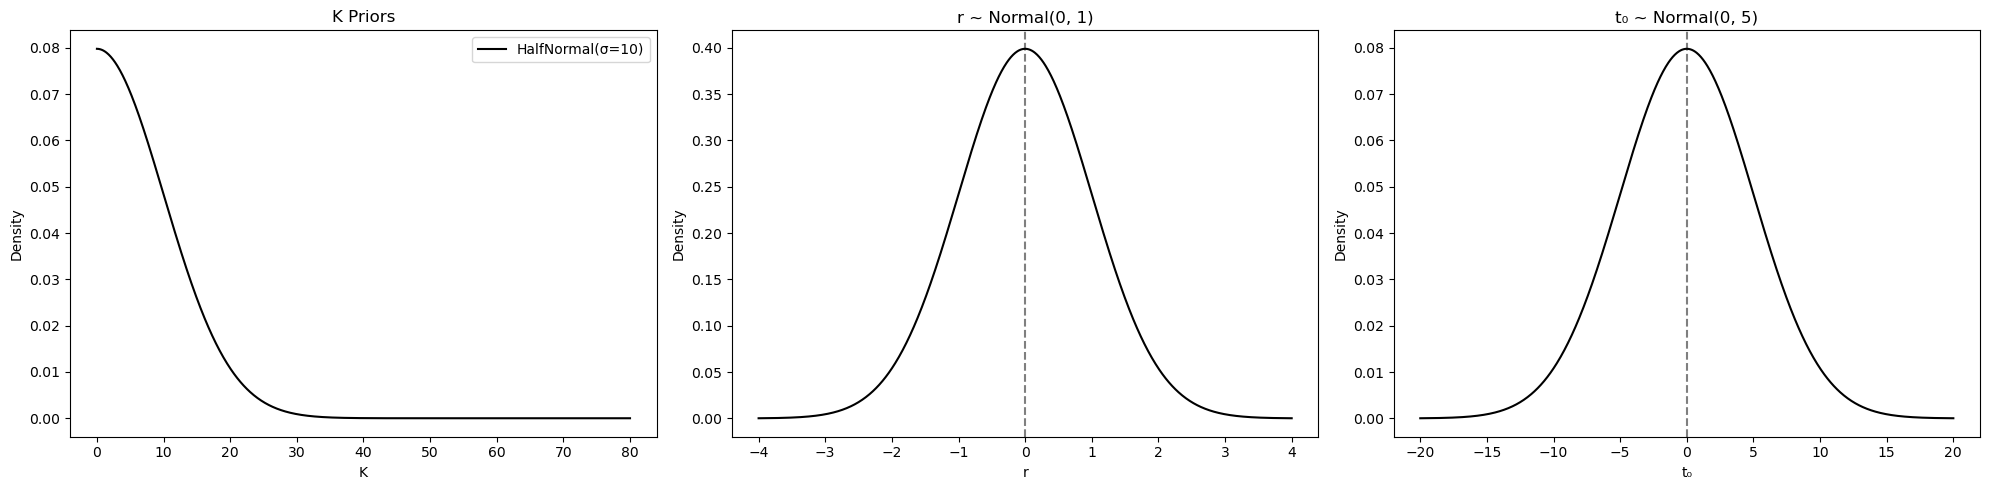

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

halfnormal_sigma = 10 # K ~ HalfNormal
gamma_alpha, gamma_beta = 2.0, 0.1               # K ~ Gamma

log_mu = 5
lognormal_mu, lognormal_sigma = np.log(log_mu), 2.0  # K ~ LogNormal
r_mu, r_sigma = 0, 1                             # r ~ Normal
t0_mu, t0_sigma = 0, 5                           # t0 ~ Normal

# x range 
x_K = np.linspace(0.01, 80, 1000)
x_r = np.linspace(r_mu - 4 * r_sigma, r_mu + 4 * r_sigma, 1000)
x_t0 = np.linspace(t0_mu - 4 * t0_sigma, t0_mu + 4 * t0_sigma, 1000)

# Distribution calculation
pdf_K_halfnormal = stats.halfnorm.pdf(x_K, scale=halfnormal_sigma)
pdf_K_lognormal = stats.lognorm.pdf(x_K, s=lognormal_sigma, scale=np.exp(lognormal_mu))
pdf_K_gamma = stats.gamma.pdf(x_K, a=gamma_alpha, scale=1/gamma_beta)

pdf_r = stats.norm.pdf(x_r, loc=r_mu, scale=r_sigma)
pdf_t0 = stats.norm.pdf(x_t0, loc=t0_mu, scale=t0_sigma)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# K subplot (3 types of prior)
axes[0].plot(x_K, pdf_K_halfnormal, label=f"HalfNormal(σ={halfnormal_sigma})", color="black")
#axes[0].plot(x_K, pdf_K_lognormal, label=f"LogNormal(μ=log({log_mu}), σ={lognormal_sigma})", color="blue", linestyle='--')
#axes[0].plot(x_K, pdf_K_gamma, label=f"Gamma(α={gamma_alpha}, β={gamma_beta})", color="green", linestyle=':')

axes[0].set_title("K Priors")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Density")
axes[0].legend()

# r subplot
axes[1].plot(x_r, pdf_r, color='black')
axes[1].axvline(r_mu, color='black', linestyle='--', alpha=0.5)
axes[1].set_title("r ~ Normal(0, 1)")
axes[1].set_xlabel("r")
axes[1].set_ylabel("Density")

# t0 subplot
axes[2].plot(x_t0, pdf_t0, color='black')
axes[2].axvline(t0_mu, color='black', linestyle='--', alpha=0.5)
axes[2].set_title("t₀ ~ Normal(0, 5)")
axes[2].set_xlabel("t₀")
axes[2].set_ylabel("Density")

plt.tight_layout()
plt.savefig(f'../00.Figures/PLCO_Bayesian_Prior_Distribution.pdf', bbox_inches='tight')
plt.show()


## 02. Run Bayesian logistic growth model

In [ ]:
!python _bayesian_model.py

### Those MGIP->MGUS clones only 

## 03. Posterior Predictive Check

/tmp/ipykernel_11556/1292903112.py:382: DtypeWarning: Columns (25,28,92,93,120,123,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228) have mixed types. Specify dtype option on import or set low_memory=False.
  filt_reshaped2 = pd.read_csv('../data/PLCO_ms_clone.csv', sep=",")


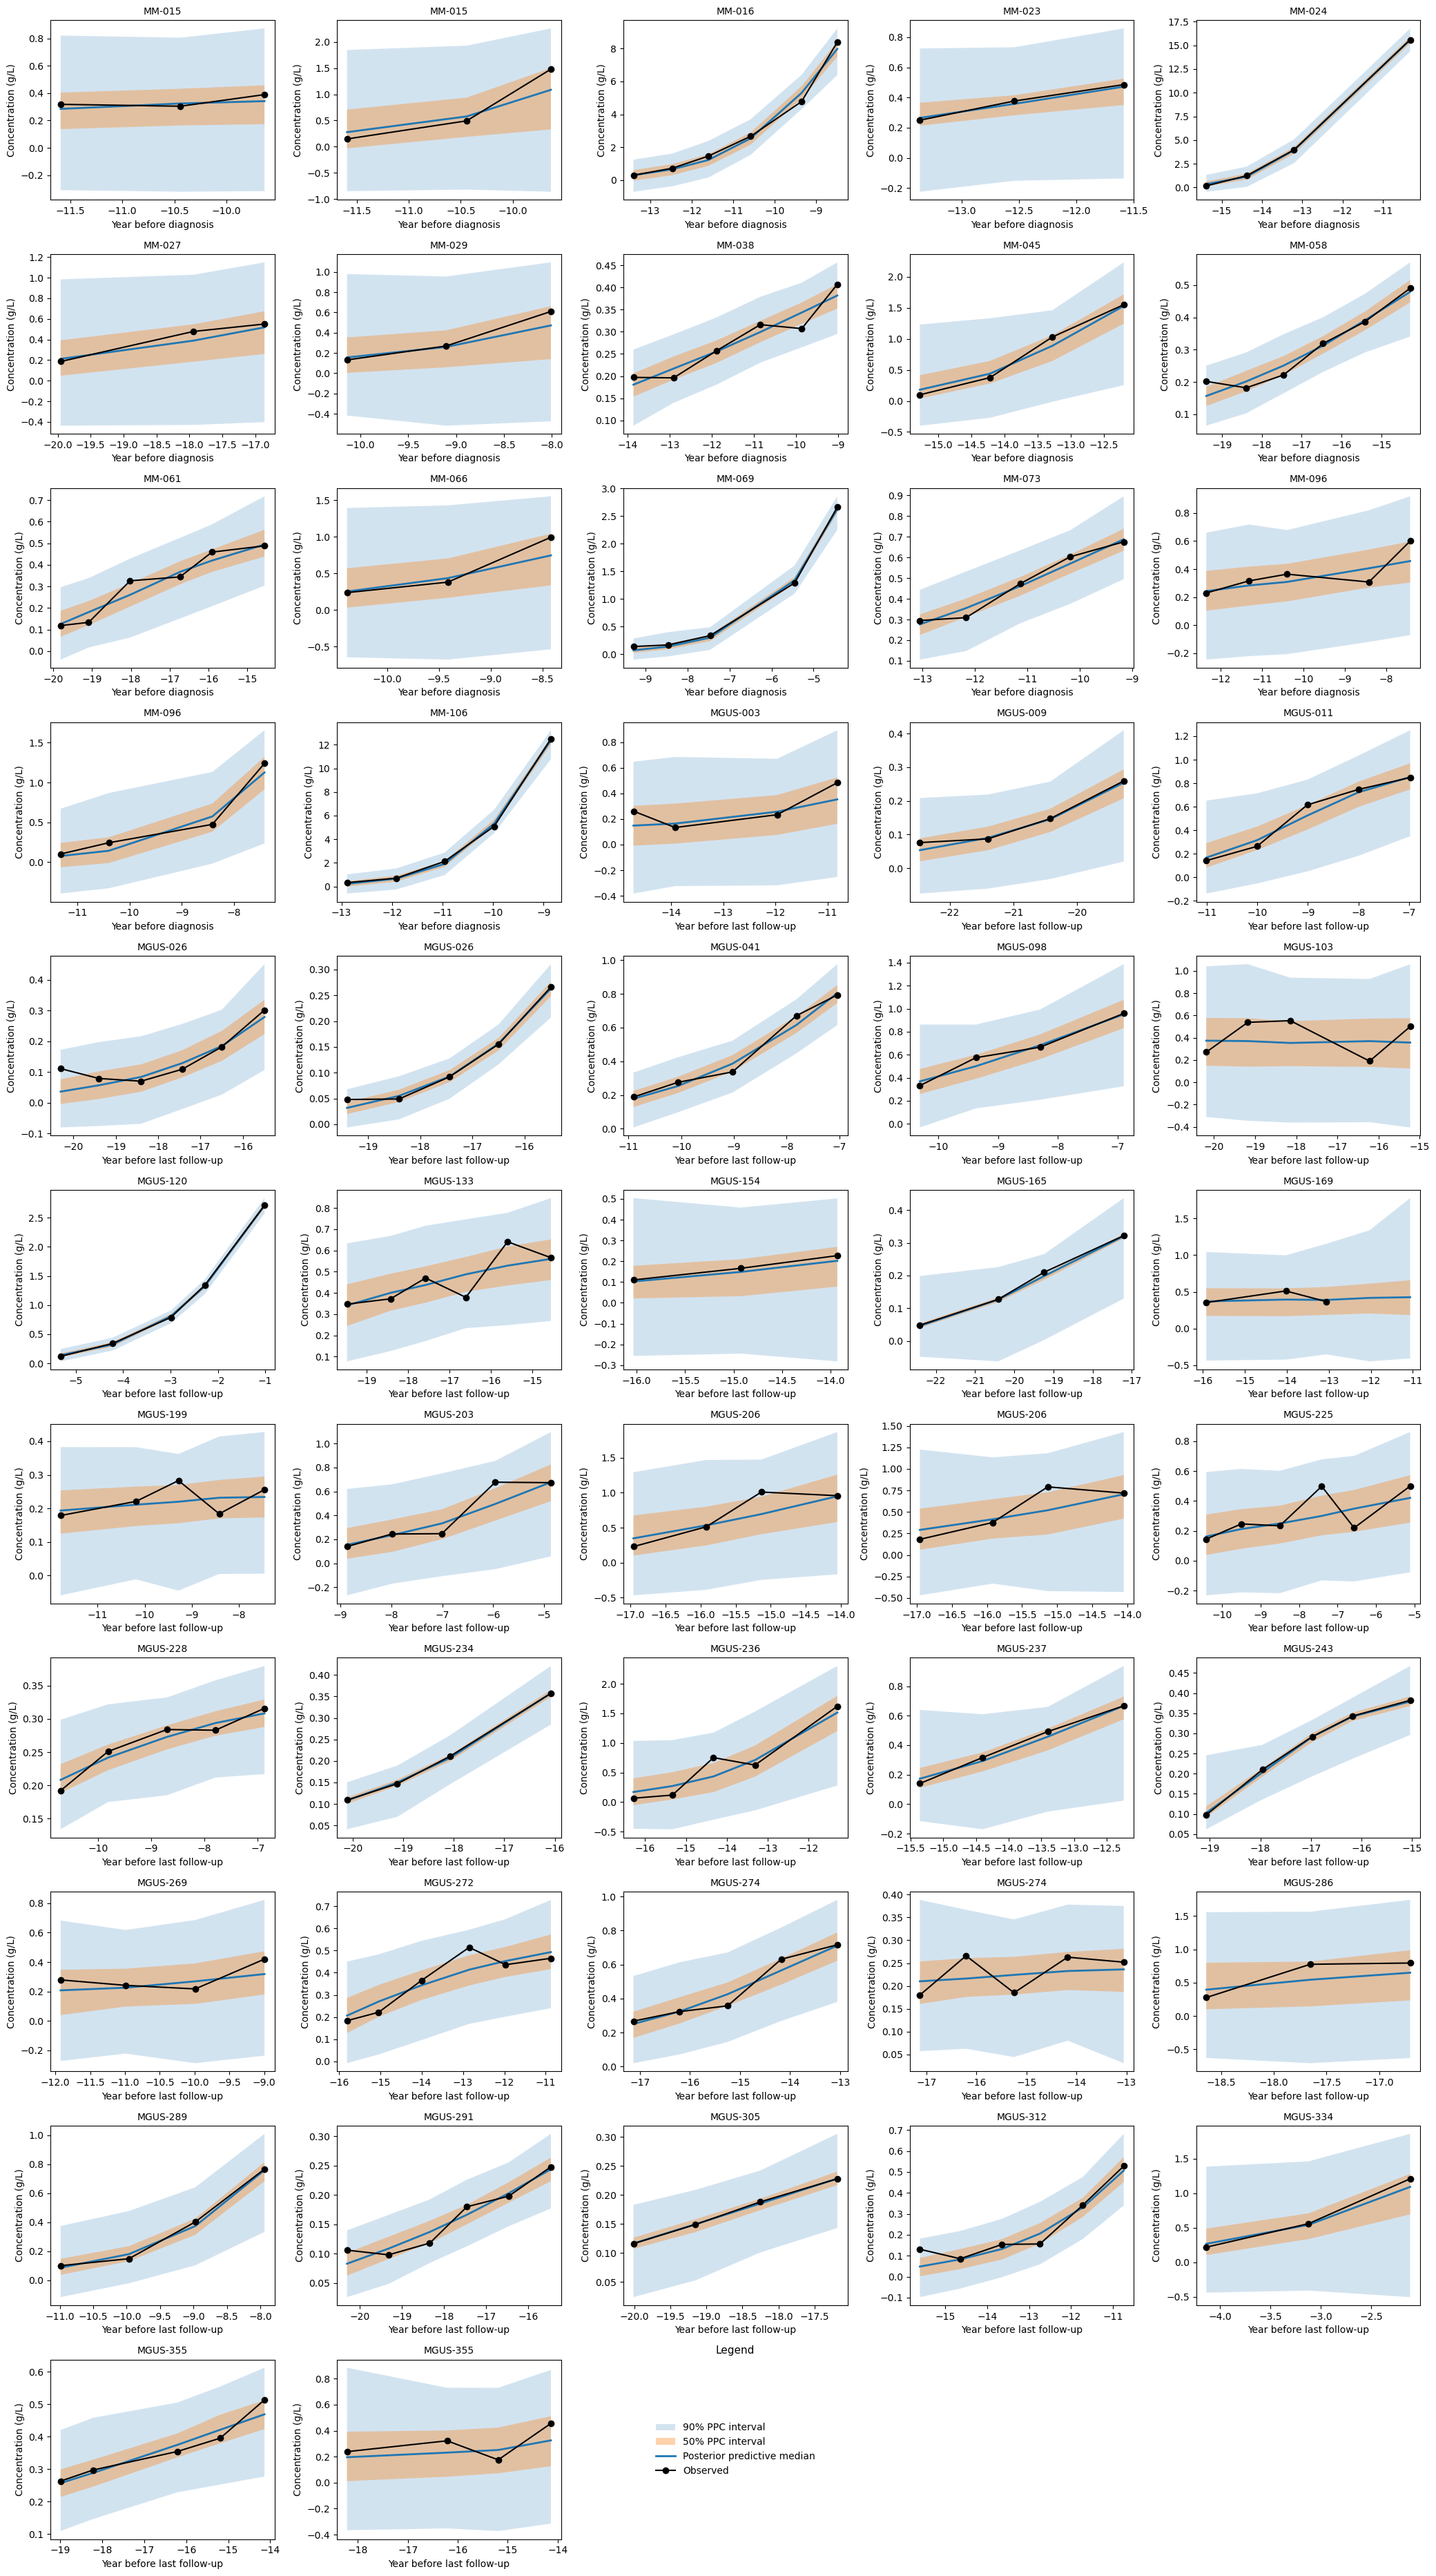

,patient_id,clone_id,pointwise_coverage_90,pointwise_coverage_50,rmse_vs_ppc_median,nrmse_vs_obs_max_pct,nrmse_vs_obs_median_pct,obs_delta_last_minus_first,ppc_pvalue_delta,obs_max,ppc_pvalue_max,error
0,MM-015,E-032997-1Clone_1,1.0,1.000000,0.035570,9.144021,11.185611,-0.071000,0.536,0.389000,0.632,NaN
1,MM-015,E-032997-1Clone_3,1.0,1.000000,0.244815,16.541543,49.759113,-1.334000,0.771,1.480000,0.373,NaN
2,MM-016,E-066387-4Clone_1,1.0,0.833333,0.295607,3.523321,14.349837,-8.090000,0.691,8.390000,0.256,NaN
3,MM-023,F-143995-1Clone_2,1.0,1.000000,0.015948,3.281473,4.230228,-0.236000,0.599,0.486000,0.568,NaN
4,MM-024,F-157972-3Clone_1,1.0,1.000000,0.110447,0.707995,4.247972,-15.443234,0.647,15.600000,0.478,NaN
5,MM-027,H-049677-0Clone_1,1.0,1.000000,0.056653,10.300531,11.852076,-0.364000,0.590,0.550000,0.612,NaN
6,MM-029,I-087748-3Clone_1,1.0,1.000000,0.080790,13.265928,30.145336,-0.478000,0.689,0.609000,0.450,NaN
7,MM-038,N-004423-0Clone_1,1.0,0.833333,0.022155,5.443528,7.856439,-0.210000,0.555,0.407000,0.304,NaN
8,MM-045,P-009501-9Clone_1,1.0,1.000000,0.088418,5.704373,12.586160,-1.451188,0.643,1.550000,0.507,NaN
9,MM-058,Q-017017-6Clone_1,1.0,0.833333,0.023983,4.894470,8.866138,-0.288000,0.295,0.490000,0.456,NaN


pointwise_coverage_90: mean=0.992, median=1.000, min=0.600, max=1.000
pointwise_coverage_50: mean=0.882, median=0.833, min=0.600, max=1.000
rmse_vs_ppc_median: mean=0.069, median=0.043, min=0.001, max=0.296
nrmse_vs_obs_max_pct: mean=8.687, median=6.111, min=0.613, max=29.329
nrmse_vs_obs_median_pct: mean=16.306, median=12.071, min=0.847, max=49.759
obs_delta_last_minus_first: mean=-1.197, median=-0.370, min=-15.443, max=-0.071
ppc_pvalue_delta: mean=0.540, median=0.564, min=0.000, max=0.771
obs_max: mean=1.387, median=0.553, min=0.227, max=15.600
ppc_pvalue_max: mean=0.505, median=0.512, min=0.000, max=0.727


In [5]:
import os
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import math

# -----------------------------------
# logistic mean function
# -----------------------------------
def logistic_mean(t, r, K, t0):
    t = np.asarray(t, dtype=float)
    return K / (1.0 + np.exp(-r * (t - t0)))


# -----------------------------------
# get observed clone data
# -----------------------------------
def get_clone_observed_data(df, patient_id, clone_id,
                            patient_col='e_2021_1015_id',
                            clone_col='Clone_ID',
                            time_col='Yr_before_dx',
                            y_col='M_Protein'):
    """
    observed trajectory for one clone
    y_col must be on the SAME scale as K in the Bayesian model.
    If your model was fit on log10 concentration, change y_col accordingly.
    """
    g = df[(df[patient_col] == patient_id) & (df[clone_col] == clone_id)].copy()
    g = g.sort_values(time_col).copy()

    t_obs = g[time_col].astype(float).values * -1
    y_obs = g[y_col].astype(float).values
    return g, t_obs, y_obs


# -----------------------------------
# read posterior from .nc
# -----------------------------------
def load_trace(trace_path):
    return az.from_netcdf(trace_path)


# -----------------------------------
# flatten posterior samples
# -----------------------------------
def extract_posterior_samples(trace, param_names=('r', 'K', 't0', 'sigma_obs')):
    out = {}
    for p in param_names:
        if p in trace.posterior:
            out[p] = trace.posterior[p].values.reshape(-1)
    return out

def simulate_posterior_predictive(trace, t_obs, n_draws=1000, seed=42):
    rng = np.random.default_rng(seed)

    samples = extract_posterior_samples(trace, param_names=('r', 'K', 't0', 'sigma_obs'))

    required = ['r', 'K', 't0']
    for p in required:
        if p not in samples:
            raise ValueError(f"Posterior parameter '{p}' not found in trace.posterior")

    n_post = len(samples['r'])
    draw_idx = rng.choice(n_post, size=min(n_draws, n_post), replace=False)

    r_s = samples['r'][draw_idx]
    K_s = samples['K'][draw_idx]
    t0_s = samples['t0'][draw_idx]

    mu_rep = np.array([
        logistic_mean(t_obs, r, K, t0)
        for r, K, t0 in zip(r_s, K_s, t0_s)
    ])  # shape: (n_draws, n_timepoints)

    if 'sigma_obs' in samples:
        sigma_s = samples['sigma_obs'][draw_idx]
        y_rep = np.array([
            rng.normal(loc=mu_rep[i], scale=sigma_s[i], size=len(t_obs))
            for i in range(len(draw_idx))
        ])
    else:
        # if sigma is absent, treat mean curve as predictive approximation
        y_rep = mu_rep.copy()

    return {
        'draw_idx': draw_idx,
        'mu_rep': mu_rep,
        'y_rep': y_rep,
        'r': r_s,
        'K': K_s,
        't0': t0_s,
        'sigma': samples.get('sigma_obs', None)
    }

def plot_clone_ppc(trace, df, patient_id, clone_id,
                   trace_dir='output/',
                   patient_col='e_2021_1015_id',
                   clone_col='Clone_ID',
                   time_col='Yr_before_dx',
                   y_col='M_Protein',
                   n_draws=1000,
                   seed=42,
                   ax=None):
    trace_path = os.path.join(trace_dir, f"{patient_id}_{clone_id}_trace.nc")
    if trace is None:
        trace = load_trace(trace_path)

    g, t_obs, y_obs = get_clone_observed_data(
        df, patient_id, clone_id,
        patient_col=patient_col,
        clone_col=clone_col,
        time_col=time_col,
        y_col=y_col
    )

    ppc = simulate_posterior_predictive(trace, t_obs, n_draws=n_draws, seed=seed)
    y_rep = ppc['y_rep']

    q05 = np.percentile(y_rep, 5, axis=0)
    q25 = np.percentile(y_rep, 25, axis=0)
    q50 = np.percentile(y_rep, 50, axis=0)
    q75 = np.percentile(y_rep, 75, axis=0)
    q95 = np.percentile(y_rep, 95, axis=0)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    ax.fill_between(t_obs, q05, q95, alpha=0.2, label='90% PPC interval')
    ax.fill_between(t_obs, q25, q75, alpha=0.35, label='50% PPC interval')
    ax.plot(t_obs, q50, linewidth=2, label='Posterior predictive median')
    ax.plot(t_obs, y_obs, 'o-', color='black', linewidth=1.5, markersize=6, label='Observed')

    ax.set_title(f"{patient_id} | {clone_id}")
    ax.set_xlabel(time_col)
    ax.set_ylabel(y_col)
    ax.legend(frameon=False)

    return {
        'obs_df': g,
        't_obs': t_obs,
        'y_obs': y_obs,
        'ppc': ppc,
        'quantiles': {'q05': q05, 'q25': q25, 'q50': q50, 'q75': q75, 'q95': q95}
    }

def compute_ppc_metrics(y_obs, y_rep):
    """
    y_obs: shape (T,)
    y_rep: shape (S, T)
    """
    q05 = np.percentile(y_rep, 5, axis=0)
    q25 = np.percentile(y_rep, 25, axis=0)
    q50 = np.percentile(y_rep, 50, axis=0)
    q75 = np.percentile(y_rep, 75, axis=0)
    q95 = np.percentile(y_rep, 95, axis=0)

    pointwise_covered_90 = ((y_obs >= q05) & (y_obs <= q95)).mean()
    pointwise_covered_50 = ((y_obs >= q25) & (y_obs <= q75)).mean()

    rmse_median = np.sqrt(np.mean((y_obs - q50) ** 2))

    # normalize RMSE by observed max (safer than mean if trajectories are skewed)
    obs_max = np.max(y_obs)
    if pd.notna(obs_max) and obs_max > 0:
        nrmse_pct = (rmse_median / obs_max) * 100
    else:
        nrmse_pct = np.nan

    # optional: normalize by observed median too
    obs_median = np.median(y_obs)
    if pd.notna(obs_median) and obs_median > 0:
        nrmse_vs_obs_median_pct = (rmse_median / obs_median) * 100
    else:
        nrmse_vs_obs_median_pct = np.nan

    # summary statistics
    obs_delta = y_obs[-1] - y_obs[0]
    rep_delta = y_rep[:, -1] - y_rep[:, 0]
    ppc_p_delta = np.mean(rep_delta >= obs_delta)

    rep_max = np.max(y_rep, axis=1)
    ppc_p_max = np.mean(rep_max >= obs_max)

    return {
        'pointwise_coverage_90': float(pointwise_covered_90),
        'pointwise_coverage_50': float(pointwise_covered_50),
        'rmse_vs_ppc_median': float(rmse_median),
        'nrmse_vs_obs_max_pct': float(nrmse_pct) if pd.notna(nrmse_pct) else np.nan,
        'nrmse_vs_obs_median_pct': float(nrmse_vs_obs_median_pct) if pd.notna(nrmse_vs_obs_median_pct) else np.nan,
        'obs_delta_last_minus_first': float(obs_delta),
        'ppc_pvalue_delta': float(ppc_p_delta),
        'obs_max': float(obs_max),
        'ppc_pvalue_max': float(ppc_p_max)
    }

def compute_clone_ppc_grid_metrics(
    clone_ids,
    patient_dict,
    df,
    trace_dir='output',
    patient_col='e_2021_1015_id',
    clone_col='Clone_ID',
    time_col='Yr_before_dx',
    y_col='Conc_1',
    n_draws=1000,
    seed=1,
    no_bayesian_values=None,
):
    if no_bayesian_values is None:
        no_bayesian_values = set()
    else:
        no_bayesian_values = set(no_bayesian_values)

    valid_clone_ids = [cid for cid in clone_ids if cid not in no_bayesian_values]

    results = []

    for clone_id in valid_clone_ids:
        patient_id = patient_dict[clone_id]
        trace_path = f"{trace_dir}/{patient_id}_{clone_id}_trace.nc"

        try:
            trace = az.from_netcdf(trace_path)

            g, t_obs, y_obs = get_clone_observed_data(
                df, patient_id, clone_id,
                patient_col=patient_col,
                clone_col=clone_col,
                time_col=time_col,
                y_col=y_col
            )

            ppc = simulate_posterior_predictive(
                trace, t_obs, n_draws=n_draws, seed=seed
            )

            metrics = compute_ppc_metrics(y_obs, ppc['y_rep'])

            results.append({
                "patient_id": patient_id,
                "clone_id": clone_id,
                **metrics
            })

        except Exception as e:
            results.append({
                "patient_id": patient_id,
                "clone_id": clone_id,
                "error": str(e)
            })

    return pd.DataFrame(results)

def plot_clone_ppc_grid(clone_ids, patient_dict, df,
                        trace_dir='output',
                        patient_col='e_2021_1015_id',
                        clone_col='Clone_ID',
                        time_col='Yr_before_dx',
                        y_col='Conc_log10',
                        n_cols=5,
                        n_draws=1000,
                        seed=1,
                        figsize_per_panel=(4.2, 3.4),
                        no_bayesian_values=None,
                        save=None,
                       ):

    if no_bayesian_values is None:
        no_bayesian_values = set()
    else:
        no_bayesian_values = set(no_bayesian_values)

    valid_clone_ids = [cid for cid in clone_ids if cid not in no_bayesian_values]
    n = len(valid_clone_ids)

    # for legend
    n_panels = n + 1
    n_rows = math.ceil(n_panels / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        squeeze=False
    )

    results = []
    axes_flat = axes.flatten()
    legend_handles = None
    legend_labels = None

    for k, clone_id in enumerate(valid_clone_ids):
        ax = axes_flat[k]
        patient_id = patient_dict[clone_id]
        trace_path = f"{trace_dir}/{patient_id}_{clone_id}_trace.nc"

        try:
            trace = az.from_netcdf(trace_path)

            res = plot_clone_ppc(
                trace=trace,
                df=df,
                patient_id=patient_id,
                clone_id=clone_id,
                trace_dir=trace_dir,
                patient_col=patient_col,
                clone_col=clone_col,
                time_col=time_col,
                y_col=y_col,
                n_draws=n_draws,
                seed=seed,
                ax=ax
            )

            metrics = compute_ppc_metrics(res['y_obs'], res['ppc']['y_rep'])
            results.append({
                "patient_id": patient_id,
                "clone_id": clone_id,
                **metrics
            })

            ax.set_title(f"{patient_id}", fontsize=10)
            ax.set_ylabel('Concentration (g/L)')
            if patient_id.split("-")[0] == 'MM':
                ax.set_xlabel('Year before diagnosis')
            else:
                ax.set_xlabel('Year before last follow-up')

            # legend info save --> off for real legend 
            if legend_handles is None:
                legend_handles, legend_labels = ax.get_legend_handles_labels()

            leg = ax.get_legend()
            if leg is not None:
                leg.remove()

        except Exception as e:
            ax.axis("off")
            ax.text(0.5, 0.5, f"Failed\n{clone_id}\n{e}",
                    ha='center', va='center', fontsize=9)
            results.append({
                "patient_id": patient_id,
                "clone_id": clone_id,
                "error": str(e)
            })

    # last empty part as legend 
    legend_ax = axes_flat[n]
    legend_ax.axis("off")
    if legend_handles is not None:
        legend_ax.legend(
            legend_handles,
            legend_labels,
            loc='center',
            frameon=False,
            fontsize=10
        )
        legend_ax.set_title("Legend", fontsize=11)

    for j in range(n + 1, len(axes_flat)):
        axes_flat[j].axis("off")

    plt.tight_layout()
    
    if save:
        plt.savefig(save, bbox_inches='tight')
    plt.show()

    return pd.DataFrame(results)

########## Running 

mm_progressing_clones = ['E-032997-1Clone_1', 'E-032997-1Clone_3', 'E-066387-4Clone_1', 'F-143995-1Clone_2', 'F-157972-3Clone_1', 'H-049677-0Clone_1', 'I-087748-3Clone_1', 'N-004423-0Clone_1', 'P-009501-9Clone_1', 'Q-017017-6Clone_1', 'R-016550-7Clone_5', 'R-121148-2Clone_1', 'R-125090-1Clone_1', 'S-004464-4Clone_1', 'S-043218-8Clone_1', 'V-051474-6Clone_1', 'V-051474-6Clone_3', 'W-055282-9Clone_2']
mgus_progressing_clones = ['A-054584-0Clone_1', 'A-085562-9Clone_1', 'A-117449-0Clone_3', 'B-094914-1Clone_1', 'B-094914-1Clone_2', 'C-038737-5Clone_4', 'C-096391-9Clone_1', 'J-088487-6Clone_1', 'K-004231-7Clone_5', 'M-052041-2Clone_3', 'M-097499-0Clone_3', 'O-010904-2Clone_1', 'P-061116-2Clone_1', 'P-116700-7Clone_4', 'Q-030535-1Clone_1', 'Q-095002-3Clone_1', 'S-040365-0Clone_6', 'S-067230-4Clone_3', 'S-113265-4Clone_3', 'S-113265-4Clone_7', 'T-090433-5Clone_1', 'T-104671-4Clone_1', 'U-002549-6Clone_4', 'U-034418-5Clone_1', 'U-038126-0Clone_2', 'U-071084-9Clone_2', 'V-046380-2Clone_1', 'V-074082-0Clone_4', 'V-093621-3Clone_1', 'V-093621-3Clone_2', 'V-137118-7Clone_2', 'V-149403-8Clone_6', 'V-158421-9Clone_1', 'W-105493-1Clone_4', 'W-137173-1Clone_8', 'X-153716-9Clone_2', 'Z-006982-4Clone_1', 'Z-006982-4Clone_6']

clone_dict = {'Progressor' : mm_progressing_clones,
              'Non-progressors' : mgus_progressing_clones
             }

disease_dict = {1 : 'Progressor', 2 : 'Non-progressors'}

filt_reshaped2 = pd.read_csv('../data/PLCO_ms_clone.csv', sep=",")

patient_dict = dict(zip(filt_reshaped2['Clone_ID'], filt_reshaped2['e_2021_1015_id']))

## only two timepoints
no_bayesian_dict = {
    'MM-065' : 'R-121148-2Clone_1',
    'MGUS-035' : 'C-038737-5Clone_4',
    'MGUS-119' : 'M-052041-2Clone_3', 
    'MGUS-156' : 'P-116700-7Clone_4',
}


clone_ids = mm_progressing_clones + mgus_progressing_clones
        
plot_clone_ppc_grid(clone_ids, patient_dict, filt_reshaped2,
                        trace_dir='../data',
                        patient_col='e_2021_1015_id',
                        clone_col='Clone_ID',
                        time_col='Yr_before_dx',
                        y_col='Conc_1',
                        n_cols=5,
                        n_draws=1000,
                        seed=1,
                        figsize_per_panel=(4.2, 3.4),
                        no_bayesian_values=no_bayesian_dict.values(),
                        save='../00.Figures/PLCO_Posterior_Predictive_Check.pdf',
                   
                   )

# pointwise_coverage_90: proportion of observed timepoints falling within the 90% posterior predictive interval
# rmse_vs_ppc_median: RMSE between observed values and the posterior predictive median trajectory
# ppc_pvalue_delta: posterior predictive p-value for reproducing the observed change from first to last timepoint
# ppc_pvalue_max: posterior predictive p-value for reproducing the observed maximum value

ppc_metrics_df = compute_clone_ppc_grid_metrics(
                        clone_ids, patient_dict, filt_reshaped2,
                        trace_dir='../data',
                        patient_col='e_2021_1015_id',
                        clone_col='Clone_ID',
                        time_col='Yr_before_dx',
                        y_col='Conc_1',
                        n_draws=1000,
                        seed=1,
                        #no_bayesian_values=no_bayesian_dict.values(),
                        #save='../00.Figures/PLCO_Posterior_Predictive_Check.pdf',
                   )

ppc_metrics_clean = ppc_metrics_df[ppc_metrics_df['error'].isna()].copy()

display(ppc_metrics_clean)

metric_cols = [
    'pointwise_coverage_90',
    'pointwise_coverage_50',
    'rmse_vs_ppc_median',
    'nrmse_vs_obs_max_pct',
    'nrmse_vs_obs_median_pct',
    'obs_delta_last_minus_first',
    'ppc_pvalue_delta',
    'obs_max',
    'ppc_pvalue_max'
]

total_clone_stat = pd.DataFrame({
    'mean': ppc_metrics_clean[metric_cols].mean(),
    'median': ppc_metrics_clean[metric_cols].median(),
    'min': ppc_metrics_clean[metric_cols].min(),
    'max': ppc_metrics_clean[metric_cols].max()
})

#display(total_clone_stat)

for col in metric_cols:
    s = ppc_metrics_clean[col].dropna()
    print(
        f"{col}: mean={s.mean():.3f}, median={s.median():.3f}, "
        f"min={s.min():.3f}, max={s.max():.3f}"
    )

## 04. Parameter comparison

### 04-1. Between MM Progressors and MGUS non-progressors

*********************** MGIP->MS-MGUS clones in Progressor ***********************


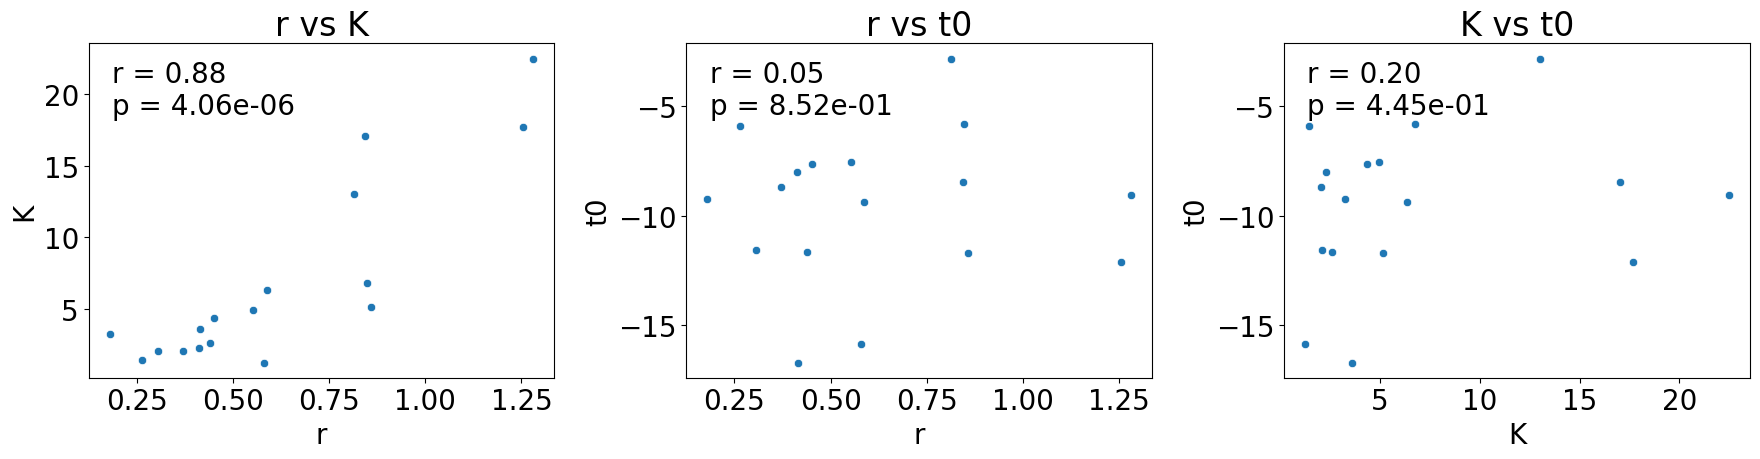

### R-121148-2Clone_1 in MM-065 has only two timepoint, therefore no Bayesian modelling result available
K, total=17, prob_80=2, 11.76%


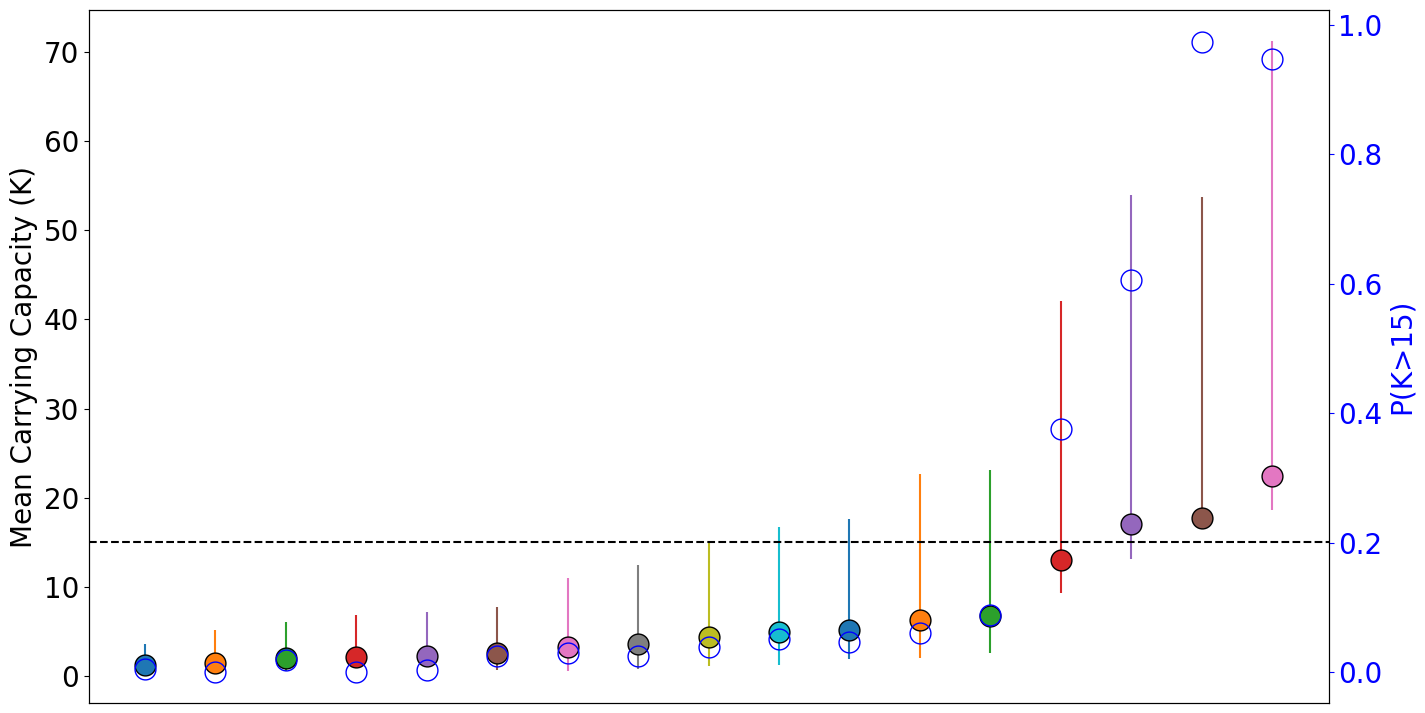

*********************** MGIP->MS-MGUS clones in Non-progressors ***********************


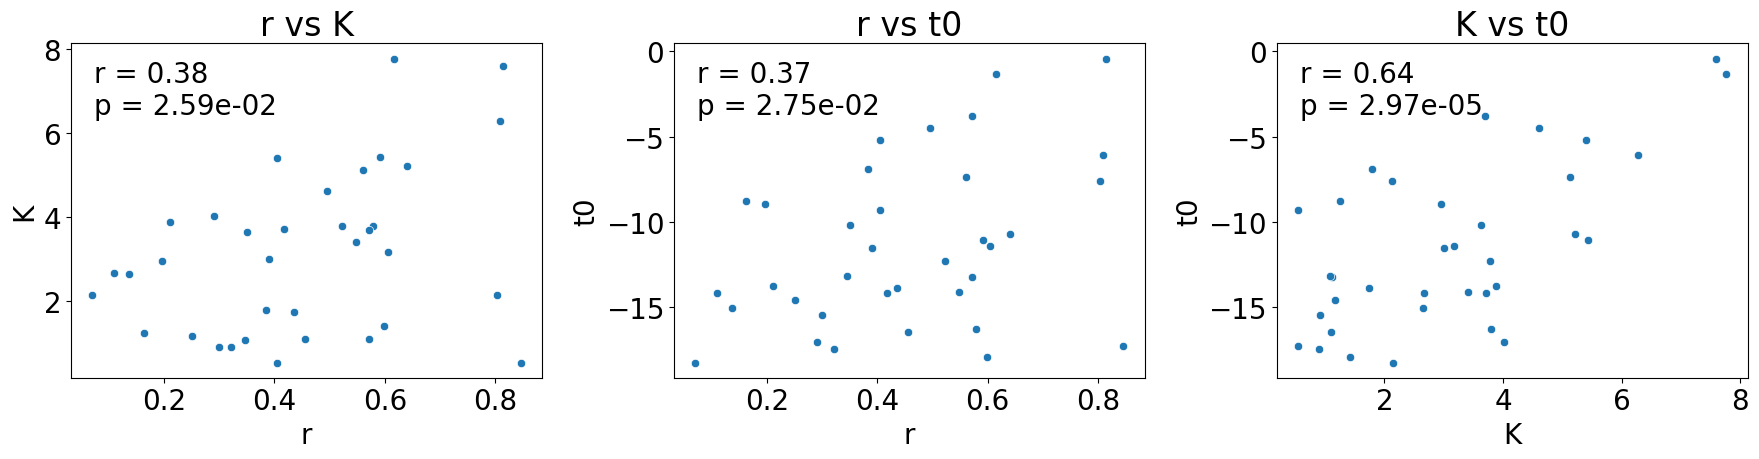

### C-038737-5Clone_4 in MGUS-035 has only two timepoint, therefore no Bayesian modelling result available
### M-052041-2Clone_3 in MGUS-119 has only two timepoint, therefore no Bayesian modelling result available
### P-116700-7Clone_4 in MGUS-156 has only two timepoint, therefore no Bayesian modelling result available
K, total=35, prob_80=0, 0.00%


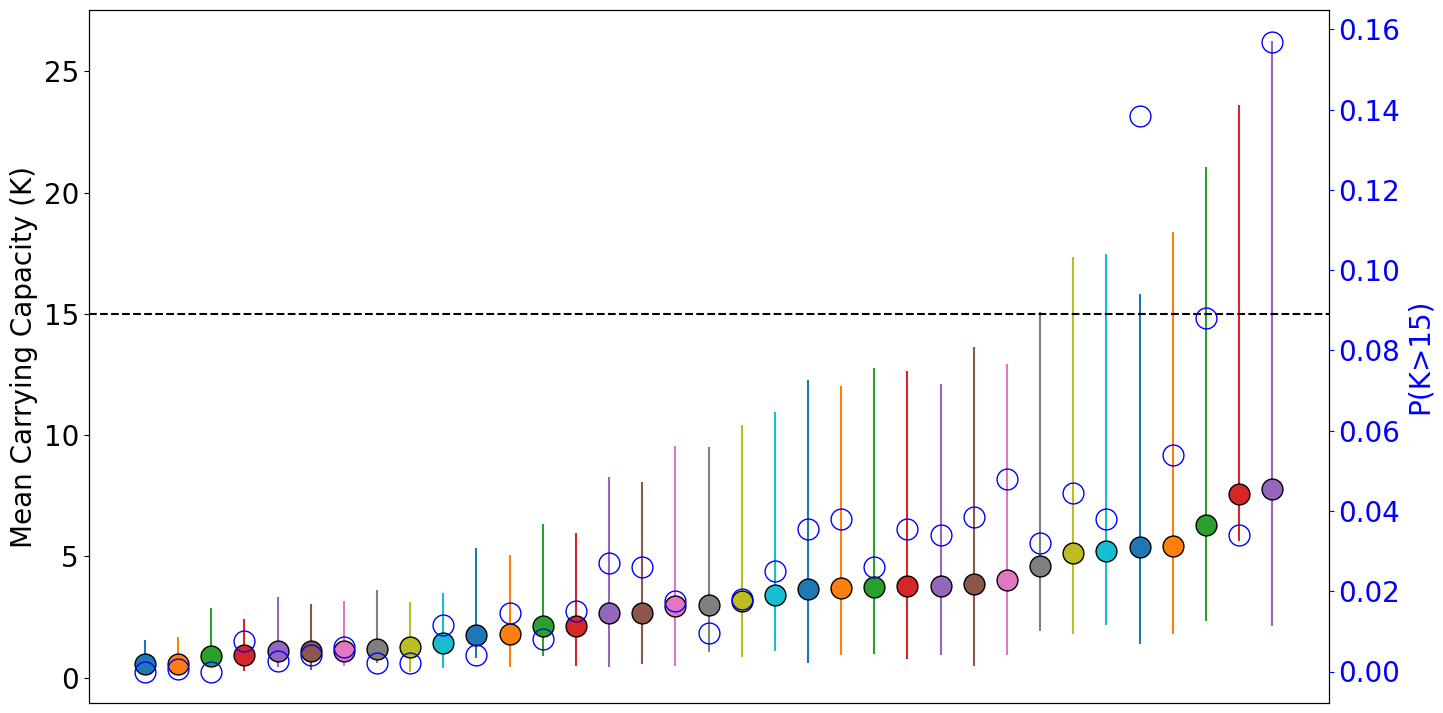

[Without IgM] r_mean: Progressors: Median = 0.6, Range = 0.2 to 1.3
[Without IgM] r_mean: Non-progressors: Median = 0.4, Range = 0.1 to 0.8


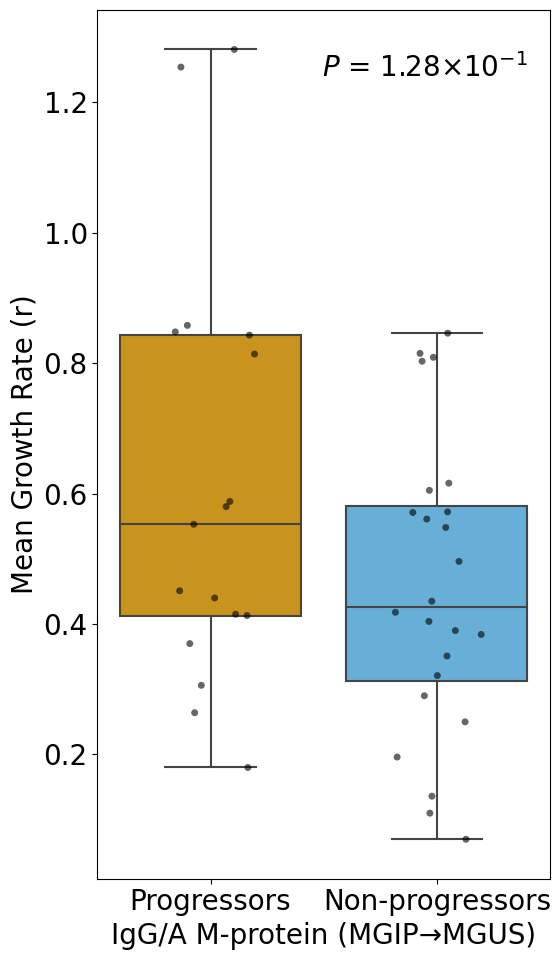

[Without IgM] K_mean: Progressors: Median = 4.4, Range = 1.2 to 22.5
[Without IgM] K_mean: Non-progressors: Median = 3.1, Range = 0.5 to 7.8


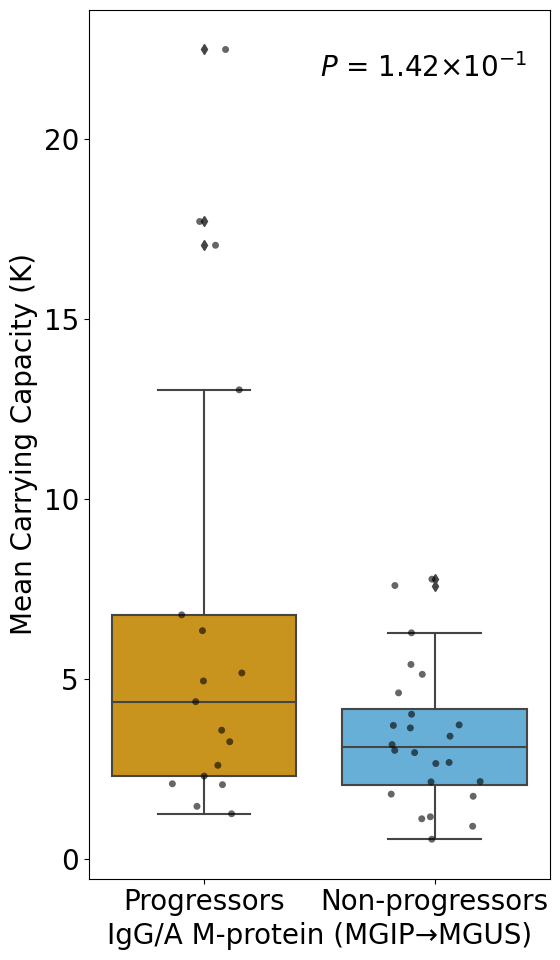

In [6]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.stats import fisher_exact, chi2_contingency
import itertools
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import pearsonr

name_dict = {'r' : 'Mean Growth Rate (r)', 
             'K' : 'Mean Carrying Capacity (K)',
             't0' : 'Mean Inflection Point (t0)'}


def get_data(patient_id, clone_id, x, hdi_prob, threshold):
    trace = az.from_netcdf(f'../data/{patient_id}_{clone_id}_trace.nc')

    posterior_distribution = trace.posterior[x].values.reshape(-1)

    prob = np.mean(posterior_distribution > threshold)
    
    summary = az.summary(trace, hdi_prob=hdi_prob)
    
    mean = summary.loc[x, "mean"]

    hdi_values = summary.loc[x].filter(like="hdi_").to_dict()
    
    hdi_keys = sorted(hdi_values.keys())  # Sort to ensure correct order
    lower_hdi, upper_hdi = hdi_values[hdi_keys[0]], hdi_values[hdi_keys[1]]
    
    # Calculate 25% and 75% quantiles
    q25, q75 = np.percentile(posterior_distribution, [25, 75])

    return mean, lower_hdi, upper_hdi, prob, posterior_distribution, q25, q75

def compare_bayes_groups(A, B, data, x, n_draw=5000, seed=42):
    rng = np.random.default_rng(seed)
    
    samplesA, samplesB = data[A], data[B]
    
    diff_samples = []
    for _ in range(n_draw):
        valA = rng.choice(samplesA)
        valB = rng.choice(samplesB)
        diff_samples.append(valA - valB)

    diff_samples = np.array(diff_samples)
    p_A_greater_B = np.mean(diff_samples>0)
    lower, upper = np.percentile(diff_samples, [2.5,97.5])
    return {f"P({A}>{B}) in {x}": p_A_greater_B, "diff_mean": diff_samples.mean(), 
            "diff_CI_2.5": lower, "diff_CI_97.5": upper}
    
filt_reshaped2 = pd.read_csv('../data/PLCO_ms_clone.csv', sep=",")

disease_dict = {1 : 'Progressor', 2 : 'Non-progressors'}

stat_table = {}

mm_progressing_clones = ['E-032997-1Clone_1', 'E-032997-1Clone_3', 'E-066387-4Clone_1', 'F-143995-1Clone_2', 'F-157972-3Clone_1', 'H-049677-0Clone_1', 'I-087748-3Clone_1', 'N-004423-0Clone_1', 'P-009501-9Clone_1', 'Q-017017-6Clone_1', 'R-016550-7Clone_5', 'R-121148-2Clone_1', 'R-125090-1Clone_1', 'S-004464-4Clone_1', 'S-043218-8Clone_1', 'V-051474-6Clone_1', 'V-051474-6Clone_3', 'W-055282-9Clone_2']
mgus_progressing_clones = ['A-054584-0Clone_1', 'A-085562-9Clone_1', 'A-117449-0Clone_3', 'B-094914-1Clone_1', 'B-094914-1Clone_2', 'C-038737-5Clone_4', 'C-096391-9Clone_1', 'J-088487-6Clone_1', 'K-004231-7Clone_5', 'M-052041-2Clone_3', 'M-097499-0Clone_3', 'O-010904-2Clone_1', 'P-061116-2Clone_1', 'P-116700-7Clone_4', 'Q-030535-1Clone_1', 'Q-095002-3Clone_1', 'S-040365-0Clone_6', 'S-067230-4Clone_3', 'S-113265-4Clone_3', 'S-113265-4Clone_7', 'T-090433-5Clone_1', 'T-104671-4Clone_1', 'U-002549-6Clone_4', 'U-034418-5Clone_1', 'U-038126-0Clone_2', 'U-071084-9Clone_2', 'V-046380-2Clone_1', 'V-074082-0Clone_4', 'V-093621-3Clone_1', 'V-093621-3Clone_2', 'V-137118-7Clone_2', 'V-149403-8Clone_6', 'V-158421-9Clone_1', 'W-105493-1Clone_4', 'W-137173-1Clone_8', 'X-153716-9Clone_2', 'Z-006982-4Clone_1', 'Z-006982-4Clone_6']

clone_dict = {'Progressor' : mm_progressing_clones,
              'Non-progressors' : mgus_progressing_clones
             }

all_results = []

no_bayesian_dict = {
    'Progressor' : ['MM-065:R-121148-2Clone_1'],
    'Non-progressors' : ['MGUS-035:C-038737-5Clone_4', 'MGUS-119:M-052041-2Clone_3', 'MGUS-156:P-116700-7Clone_4',],
} ## only two timepoints

for disease in disease_dict.keys():
#for disease in [1]:
    disease_name = disease_dict[disease]
    print(f"*********************** MGIP->MS-MGUS clones in {disease_name} ***********************")
    filtered_df = filt_reshaped2[filt_reshaped2['casestat'] == disease]
    filtered_df = filtered_df.groupby(['e_2021_1015_id', 'Clone_ID']).filter(lambda x: len(x) > 2)

    ## MGIP progressing clones
    filtered_df = filtered_df[filtered_df['Clone_ID'].isin(clone_dict[disease_name])]
    
    #flc_ratio < 0.26 or flc_ratio > 1.65 
    dict_flc_landgren = (
        filtered_df.sort_values(by=['Yr_before_dx'], ascending=False) 
        .groupby('Clone_ID')
        .apply(lambda x: list(x['flc_ratio']))
        .to_dict()
    )
    
    dict_flc_dfci = (
        filtered_df.sort_values(by=['Yr_before_dx'], ascending=False)
        .groupby('Clone_ID')
        .apply(lambda x: list(x['FLCRatio']))
        .to_dict()
    )
    
    dict_years = (
        filtered_df.sort_values(by=['Yr_before_dx'], ascending=False)
        .groupby('Clone_ID')
        .apply(lambda x: list(x['Yr_before_dx']))
        .to_dict()
    )
    
    ## baseline
    idx = filtered_df.groupby(['e_2021_1015_id', 'Clone_ID'])['Yr_before_dx'].idxmax()

    filtered_df = filtered_df.loc[idx].reset_index(drop=True)

    #### Create a result_df
    results_dict = {} 

    for x in ['r', 'K', 't0']:
        threshold = 15 if x == 'K' else (0.5 if x == 'r' else 0)

        for _, row in filtered_df.iterrows():
            patient_id = row['e_2021_1015_id']
            clone_id = row['Clone_ID']
            key = (patient_id, clone_id)

            mean, lower, upper, prob, post_dist, q25, q75 = get_data(patient_id, clone_id, x, hdi_prob=0.95, 
                                                           threshold=threshold)

            if key not in results_dict:
                results_dict[key] = {
                    "patient_id": patient_id,
                    "clone_id": clone_id,
                    "MSdxBS": row['Mass_Spect_Diagnosis_SK_New'],
                    "isotype": row['Type_1'],
                    "isotype_heavy": row['Type_heavy'],
                    "flc_landgren": dict_flc_landgren[row['Clone_ID']],
                    "flc_dfci": dict_flc_dfci[row['Clone_ID']],
                    "years": dict_years[row['Clone_ID']],
                }

            results_dict[key][f"{x}_mean"] = mean
            results_dict[key][f"{x}_lower_hdi"] = q25#lower
            results_dict[key][f"{x}_upper_hdi"] = q75#upper
            results_dict[key][f"{x}_prob"] = prob

    # DataFrame
    results_df = pd.DataFrame(list(results_dict.values()))
    results_df["Group"] = disease_name 
    all_results.append(results_df)
        
    #### Scatter plot
    # Only keep rows where all three parameters are present
    df_plot = results_df.dropna(subset=['r_mean', 'K_mean', 't0_mean'])

    # all pair combination
    pairs = [('r_mean', 'K_mean'), ('r_mean', 't0_mean'), ('K_mean', 't0_mean')]

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    plt.rcParams.update({'font.size': 20})
    
    for i, (x1, x2) in enumerate(pairs):
        sns.scatterplot(data=df_plot, x=x1, y=x2, ax=axes[i])
        x1_name, x2_name = x1.split("_")[0], x2.split("_")[0]
        axes[i].set_title(f'{x1_name} vs {x2_name}')
        axes[i].set_xlabel(x1_name)
        axes[i].set_ylabel(x2_name)

        # Pearson correlation 
        r_val, p_val = pearsonr(df_plot[x1], df_plot[x2])

        axes[i].text(0.05, 0.95,
                     f"r = {r_val:.2f}\np = {p_val:.2e}",
                     transform=axes[i].transAxes,
                     fontsize=20,
                     ha='left', va='top',
                     #bbox=dict(facecolor='white', edgecolor='black', alpha=0.8)
                    )

    plt.tight_layout()
    plt.savefig(f'../00.Figures/PLCO_Bayesian_scatter_{disease_dict[disease]}.pdf', bbox_inches='tight')
    plt.show()


    #### Posterior K distribution 
    no_bayesian_list = no_bayesian_dict[disease_name]
    for bay_value in no_bayesian_list: 
        pts, clone_id = bay_value.split(":")
        print(f"### {clone_id} in {pts} has only two timepoint, therefore no Bayesian modelling result available")
    for x in ['K']:
        threshold = 15
        df_sorted = results_df.sort_values(by=[f"{x}_mean"], ascending=[True])
        df_sorted = df_sorted.dropna(subset=[f"{x}_mean"])
        df_sorted = df_sorted.replace([np.inf, -np.inf], np.nan)

        #### Print P(K > 15) >= 0.8
        prob_80 = len(df_sorted[df_sorted[f'{x}_prob'] >= 0.8])
        total = len(df_sorted)
        prob_80_perc = prob_80 / total * 100
        print(f"{x}, total={total}, prob_80={prob_80}, {prob_80_perc:.2f}%")

        mgip_clones = df_sorted[df_sorted['MSdxBS'].str.contains('MGIP')]

        ############ Visualization ###############
        #### 1. Distribution of each parameter
        fig, ax1 = plt.subplots(figsize=(16, 9))

        # 95% CI
        yerr_lower = df_sorted[f"{x}_mean"] - df_sorted[f"{x}_lower_hdi"]
        yerr_upper = df_sorted[f"{x}_mean"] + df_sorted[f"{x}_upper_hdi"]

        for idx, (msdxbs, clone_id, mean_val, yerr_low, yerr_high) in enumerate(
            zip(df_sorted['MSdxBS'], df_sorted['clone_id'], df_sorted[f'{x}_mean'], yerr_lower, yerr_upper)
        ):

            ax1.errorbar(
                idx, mean_val, yerr=[[yerr_low], [yerr_high]],
                fmt='o', markersize=15,
                linestyle='none', mec='black'
            )

        ax1.set_xticks([])

        ax1.set_ylabel(name_dict[x], color='black', fontsize=20)

        plt.axhline(threshold, color='black', linestyle='--')

        #### 2. Create the second y-axis: Probability (right side)
        ax2 = ax1.twinx()

        for idx, (clone_id, prob_val) in enumerate(zip(df_sorted['clone_id'], df_sorted[f'{x}_prob'])):
            ax2.errorbar(idx, prob_val, 
                         fmt='o', linestyle='none', mfc='none', mec='blue', markersize=15)

        ax2.set_ylabel(f'P({x}>{threshold})', color='blue', fontsize=20)
        ax2.tick_params(axis='y', colors='blue')

        plt.savefig(f'../00.Figures/PLCO_Bayesian_{x}_distribution_{disease_dict[disease]}.pdf', bbox_inches='tight')
        plt.show()
        
results_all_df = pd.concat(all_results, ignore_index=True)

results_no_igm_df = results_all_df[results_all_df["isotype_heavy"] != "IgM"].copy()

custom_palette = {
    "Progressors": "#e69f00",  
    "Non-progressors": "#56b4e9",  
}

## Comparison ** Without IgM **
for param in ["r_mean", "K_mean"]:
    plt.figure(figsize=(6, 10))
    plt.rcParams.update({'font.size': 20})
    
    results_no_igm_df["Group"] = results_no_igm_df["Group"].replace({
        "Progressor": "Progressors",
        "Non-progressors": "Non-progressors"  
    })
    
    for group in ["Progressors", "Non-progressors"]:
        values = results_no_igm_df[results_no_igm_df["Group"] == group][param].dropna()
        if len(values) == 0:
            continue
            
        median_val = values.median()
        min_val = values.min()
        max_val = values.max()
        
        print(f"[Without IgM] {param}: {group}: Median = {median_val:.1f}, Range = {min_val:.1f} to {max_val:.1f}")
    
    ax = sns.boxplot(data=results_no_igm_df, x="Group", y=param, palette=custom_palette)
    sns.stripplot(data=results_no_igm_df, x="Group", y=param, color='black', alpha=0.6, jitter=0.2)

    # Mann-Whitney U test
    prog_vals = results_no_igm_df[results_no_igm_df["Group"] == "Progressors"][param].dropna()
    nonprog_vals = results_no_igm_df[results_no_igm_df["Group"] == "Non-progressors"][param].dropna()
    
    if len(prog_vals) > 0 and len(nonprog_vals) > 0:
        _, pval = mannwhitneyu(prog_vals, nonprog_vals, alternative='two-sided')

        base, exponent = f'{pval:.2e}'.split('e')
        exponent = int(exponent)  # e.g., -3
        formatted_pval = f"{base}×10$^{{{exponent}}}$"
        
        # Add p-value to top right corner
        ax.annotate(f"$\\it{{P}}$ = {formatted_pval}",
                    xy=(0.95, 0.95), xycoords='axes fraction',
                    ha='right', va='top',
                    fontsize=20)

    plt.ylabel(name_dict[param.split('_')[0]])
    plt.xlabel('IgG/A M-protein (MGIP→MGUS)')
    plt.tight_layout()
    plt.savefig(f'../00.Figures/PLCO_Bayesian_{param}_comparison_no_IgM.pdf', bbox_inches='tight')
    plt.show()

In [35]:
from scipy.stats import fisher_exact
import pandas as pd

total_mm = 17   
total_mgus = 35 

print(f"Total N -> MM: {total_mm}, MGUS: {total_mgus}\n")

mm_prob_yes = 3
mgus_prob_yes = 0

table_prob = [
    [mm_prob_yes, total_mm - mm_prob_yes],       
    [mgus_prob_yes, total_mgus - mgus_prob_yes]  
]

_, p_val_prob = fisher_exact(table_prob, alternative='two-sided')

print("### 1. P(K>15) greater than 50% Fisher's Exact Test ###")
print(pd.DataFrame(table_prob, index=['MM', 'MGUS'], columns=['Yes', 'No']))
print(f"--> p-value: {p_val_prob:.4f}\n")


mm_k_yes = 3
mgus_k_yes = 0

table_k = [
    [mm_k_yes, total_mm - mm_k_yes],
    [mgus_k_yes, total_mgus - mgus_k_yes]
]

_, p_val_k = fisher_exact(table_k, alternative='two-sided')

print("### 2. K >= 15 Fisher's Exact Test ###")
print(pd.DataFrame(table_k, index=['MM', 'MGUS'], columns=['Yes', 'No']))
print(f"--> p-value: {p_val_k:.4f}")

Total N -> MM: 17, MGUS: 35

### 1. P(K>15) greater than 50% Fisher's Exact Test ###
      Yes  No
MM      3  14
MGUS    0  35
--> p-value: 0.0308

### 2. K >= 15 Fisher's Exact Test ###
      Yes  No
MM      3  14
MGUS    0  35
--> p-value: 0.0308


### 04-2. Between Isotypes

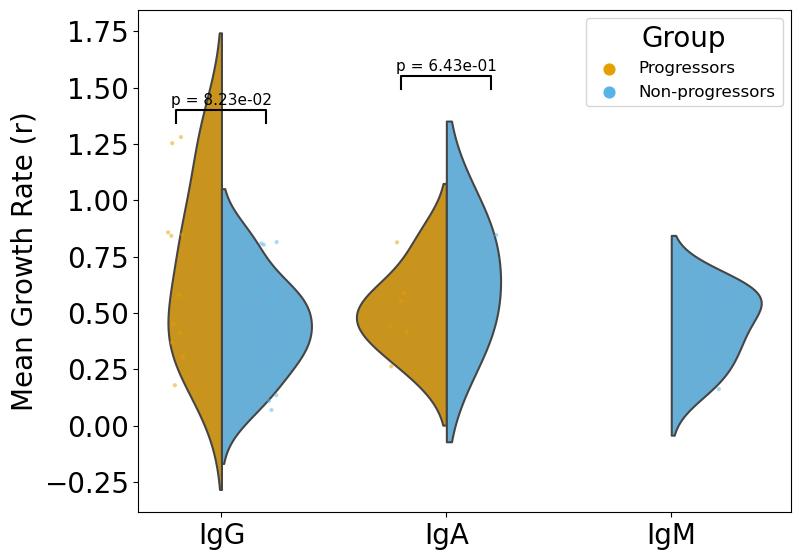

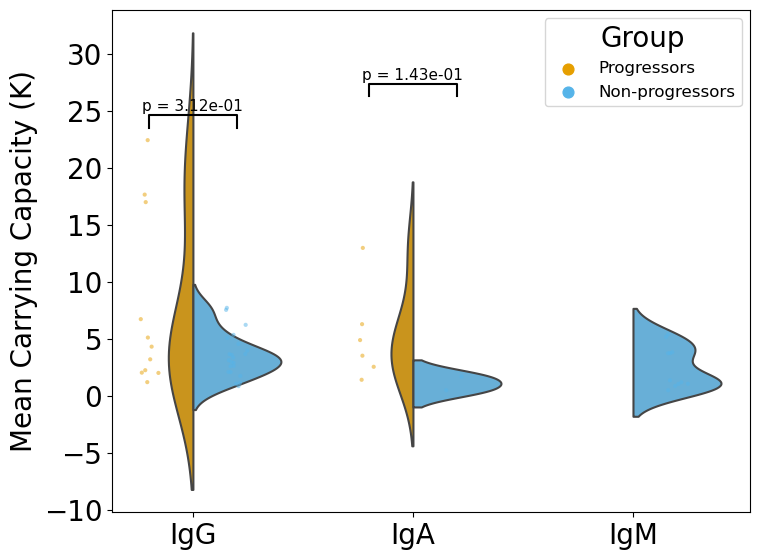

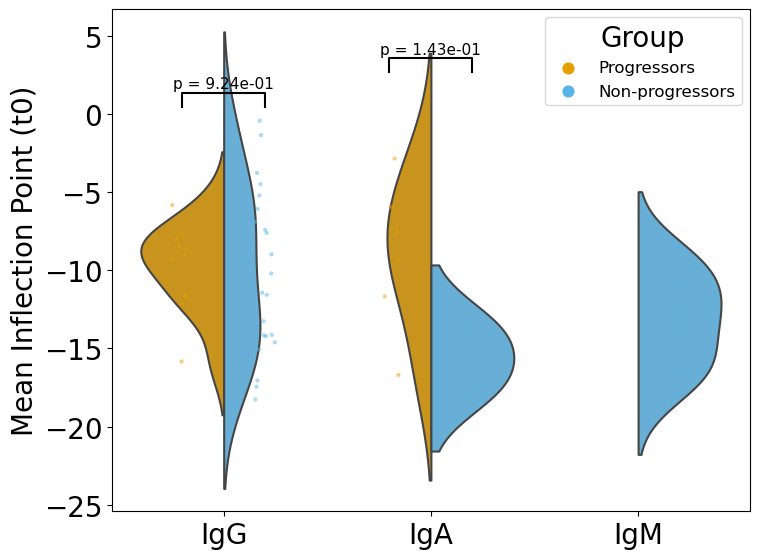

In [3]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.stats import fisher_exact, chi2_contingency
import itertools
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import pearsonr

name_dict = {'r' : 'Mean Growth Rate (r)', 
             'K' : 'Mean Carrying Capacity (K)',
             't0' : 'Mean Inflection Point (t0)'}

def get_data(patient_id, clone_id, x, hdi_prob, threshold):
    trace = az.from_netcdf(f'../data/{patient_id}_{clone_id}_trace.nc')

    posterior_distribution = trace.posterior[x].values.reshape(-1)

    prob = np.mean(posterior_distribution > threshold)
    
    summary = az.summary(trace, hdi_prob=hdi_prob)
    
    mean = summary.loc[x, "mean"]

    hdi_values = summary.loc[x].filter(like="hdi_").to_dict()
    
    hdi_keys = sorted(hdi_values.keys())  # Sort to ensure correct order
    lower_hdi, upper_hdi = hdi_values[hdi_keys[0]], hdi_values[hdi_keys[1]]
    
    # Calculate 25% and 75% quantiles
    q25, q75 = np.percentile(posterior_distribution, [25, 75])

    return mean, lower_hdi, upper_hdi, prob, posterior_distribution, q25, q75


filt_reshaped2 = pd.read_csv('../data/PLCO_ms_clone.csv', sep=",")

disease_dict = {1 : 'Progressor', 2 : 'Non-progressors'}

mm_progressing_clones = ['E-032997-1Clone_1', 'E-032997-1Clone_3', 'E-066387-4Clone_1', 'F-143995-1Clone_2', 'F-157972-3Clone_1', 'H-049677-0Clone_1', 'I-087748-3Clone_1', 'N-004423-0Clone_1', 'P-009501-9Clone_1', 'Q-017017-6Clone_1', 'R-016550-7Clone_5', 'R-121148-2Clone_1', 'R-125090-1Clone_1', 'S-004464-4Clone_1', 'S-043218-8Clone_1', 'V-051474-6Clone_1', 'V-051474-6Clone_3', 'W-055282-9Clone_2']
mgus_progressing_clones = ['A-054584-0Clone_1', 'A-085562-9Clone_1', 'A-117449-0Clone_3', 'B-094914-1Clone_1', 'B-094914-1Clone_2', 'C-038737-5Clone_4', 'C-096391-9Clone_1', 'J-088487-6Clone_1', 'K-004231-7Clone_5', 'M-052041-2Clone_3', 'M-097499-0Clone_3', 'O-010904-2Clone_1', 'P-061116-2Clone_1', 'P-116700-7Clone_4', 'Q-030535-1Clone_1', 'Q-095002-3Clone_1', 'S-040365-0Clone_6', 'S-067230-4Clone_3', 'S-113265-4Clone_3', 'S-113265-4Clone_7', 'T-090433-5Clone_1', 'T-104671-4Clone_1', 'U-002549-6Clone_4', 'U-034418-5Clone_1', 'U-038126-0Clone_2', 'U-071084-9Clone_2', 'V-046380-2Clone_1', 'V-074082-0Clone_4', 'V-093621-3Clone_1', 'V-093621-3Clone_2', 'V-137118-7Clone_2', 'V-149403-8Clone_6', 'V-158421-9Clone_1', 'W-105493-1Clone_4', 'W-137173-1Clone_8', 'X-153716-9Clone_2', 'Z-006982-4Clone_1', 'Z-006982-4Clone_6']

clone_dict = {'Progressor' : mm_progressing_clones,
              'Non-progressors' : mgus_progressing_clones
             }

igh_colors = {
    'IgG': '#66c2a5',  
    'IgA': '#fc8d62',  
    'IgM': '#8da0cb', 
}

all_results = []

for disease in disease_dict.keys():
#for disease in [1]:
    disease_name = disease_dict[disease]
    filtered_df = filt_reshaped2[filt_reshaped2['casestat'] == disease]
    filtered_df = filtered_df.groupby(['e_2021_1015_id', 'Clone_ID']).filter(lambda x: len(x) > 2)

    ## MGIP progressing clones
    filtered_df = filtered_df[filtered_df['Clone_ID'].isin(clone_dict[disease_name])]
    
    #flc_ratio < 0.26 or flc_ratio > 1.65 
    dict_flc_landgren = (
        filtered_df.sort_values(by=['Yr_before_dx'], ascending=False) 
        .groupby('Clone_ID')
        .apply(lambda x: list(x['flc_ratio']))
        .to_dict()
    )
    
    dict_flc_dfci = (
        filtered_df.sort_values(by=['Yr_before_dx'], ascending=False)
        .groupby('Clone_ID')
        .apply(lambda x: list(x['FLCRatio']))
        .to_dict()
    )
    
    dict_years = (
        filtered_df.sort_values(by=['Yr_before_dx'], ascending=False)
        .groupby('Clone_ID')
        .apply(lambda x: list(x['Yr_before_dx']))
        .to_dict()
    )
    
    #### Create a result_df
    results_dict = {}  

    for x in ['r', 'K', 't0']:
        threshold = 15 if x == 'K' else (0.5 if x == 'r' else 0)

        for _, row in filtered_df.iterrows():
            patient_id = row['e_2021_1015_id']
            clone_id = row['Clone_ID']
            key = (patient_id, clone_id)

            mean, lower, upper, prob, post_dist, q25, q75 = get_data(patient_id, clone_id, x, hdi_prob=0.95, 
                                                           threshold=threshold)

            if key not in results_dict:
                results_dict[key] = {
                    "patient_id": patient_id,
                    "clone_id": clone_id,
                    "MSdxBS": row['Baseline_Clone_Mass_Spect_Diagnosis_SK'],
                    "isotype": row['Type_1'],
                    "isotype_heavy": row['Type_heavy'],
                    "flc_landgren": dict_flc_landgren[row['Clone_ID']],
                    "flc_dfci": dict_flc_dfci[row['Clone_ID']],
                    "years": dict_years[row['Clone_ID']],
                }

            results_dict[key][f"{x}_mean"] = mean
            results_dict[key][f"{x}_lower_hdi"] = q25#lower
            results_dict[key][f"{x}_upper_hdi"] = q75#upper
            results_dict[key][f"{x}_prob"] = prob
    # All results
    all_results.append(pd.DataFrame.from_dict(results_dict, orient='index'))
    
    results_df = pd.DataFrame.from_dict(results_dict, orient='index')

    params = ['r_mean', 'K_mean', 't0_mean']
    name_dict = {
        'r_mean': 'Mean Growth Rate (r)',
        'K_mean': 'Mean Carrying Capacity (K)',
        't0_mean': 'Mean Inflection Point (t0)'
    }

        
## All results (per Prog vs non-prog in G/A/M)
# -------- Merge all --------
results_df = pd.concat(all_results, ignore_index=True)

results_df['disease'] = np.where(
    results_df['patient_id'].str.startswith('MM'), 
    'Progressors',
    'Non-progressors'
)

# -------- Plotting --------
params = ['r_mean', 'K_mean', 't0_mean']
name_dict = {
    'r_mean': 'Mean Growth Rate (r)',
    'K_mean': 'Mean Carrying Capacity (K)',
    't0_mean': 'Mean Inflection Point (t0)'
}
isotype_order = ['IgG', 'IgA', 'IgM']
hue_order = ['Progressors', 'Non-progressors']

custom_palette = {
    "Progressors": "#e69f00",  
    "Non-progressors": "#56b4e9",  
}

for p in params:
    plt.figure(figsize=(8, 6))
    sns.violinplot(
        data=results_df,
        x='isotype_heavy',
        y=p,
        hue='disease',
        order=isotype_order,
        hue_order=hue_order,
        palette=custom_palette,
        split=True,
        inner=None
    )
    sns.stripplot(
        data=results_df,
        x='isotype_heavy',
        y=p,
        hue='disease',
        order=isotype_order,
        hue_order=hue_order,
        dodge=True,
        jitter=True,
        size=3,
        alpha=0.5,
        palette=custom_palette
    )
    
    # remove legend duplicates
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), title="Group", fontsize=12)

    # stat annotation
    y_max = results_df[p].max()
    y_min = results_df[p].min()
    y_offset = (y_max - y_min) * 0.05
    current_y = y_max + y_offset

    for i, iso in enumerate(isotype_order):
        grp1 = results_df[(results_df['isotype_heavy'] == iso) & (results_df['disease'] == 'Progressors')][p]
        grp2 = results_df[(results_df['isotype_heavy'] == iso) & (results_df['disease'] == 'Non-progressors')][p]

        if len(grp1) > 0 and len(grp2) > 0:
            stat, pval = mannwhitneyu(grp1, grp2, alternative='two-sided')
            label = f"p = {pval:.2e}"

            x1 = i - 0.2
            x2 = i + 0.2

            plt.plot([x1, x1, x2, x2], [current_y, current_y + y_offset, current_y + y_offset, current_y], color='black')
            plt.text((x1 + x2) / 2, current_y + y_offset * 1.1, label, ha='center', va='bottom', fontsize=11)

            current_y += y_offset * 2.5

    plt.ylabel(name_dict[p])
    plt.xlabel("")
    plt.tight_layout()
    plt.savefig(f'../00.Figures/PLCO_Bayesian_total_{p}_comparison_prog_vs_nonprog.pdf', bbox_inches='tight')
    plt.show()